<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/decision_tree/Decision_tree_gini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd, numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/AI-python/lecture17/Decision_Tree_data.xlsx")

In [ ]:
df_dropped=df.drop(columns=["Name"])
df_dropped

,Heart Rate,Blood Pressure,Cholesterol,Blood Sugar,Illness
0,Normal,High,High,High,Yes
1,High,Low,Low,Normal,Yes
2,Low,Low,High,Low,No
3,Normal,High,Low,High,Yes
4,High,Normal,High,High,Yes
5,Low,Low,High,Normal,Yes
6,Normal,Normal,Low,Low,No
7,Normal,High,Low,Normal,No
8,Normal,Normal,Low,Low,No
9,Normal,Normal,Low,Normal,No


In [ ]:
def calculate_gini_impurity(target_series):
    """
    Calculates the Gini impurity for a given target variable Series.
    """
    # Get the counts of each class in the target series
    counts = target_series.value_counts()
    total_count = len(target_series)

    if total_count == 0:
        return 0.0 # Impurity is 0 if there are no samples

    gini = 1.0
    for count in counts:
        proportion = count / total_count
        gini -= proportion**2
    return gini

print("Defined function: calculate_gini_impurity")

Defined function: calculate_gini_impurity


In [ ]:
initial_gini = calculate_gini_impurity(df['Illness'])
print(f"Initial Gini Impurity (Root Node): {initial_gini:.3f}")

Initial Gini Impurity (Root Node): 0.496


In [ ]:
def calculate_information_gain(df, feature_name, target_name, gini_parent):
    """
    Calculates the information gain for a potential split on a given feature.
    """
    weighted_gini_children = 0.0
    total_samples = len(df)

    # Iterate through unique values of the feature
    for value in df[feature_name].unique():
        # Subset where feature equals the value
        subset = df[df[feature_name] == value]
        gini_subset = calculate_gini_impurity(subset[target_name])
        weight_subset = len(subset) / total_samples
        weighted_gini_children += weight_subset * gini_subset

    information_gain = gini_parent - weighted_gini_children
    return information_gain

print("Defined function: calculate_information_gain")

Defined function: calculate_information_gain


In [ ]:
target_name = 'Illness'
features = [col for col in df_dropped.columns if col != target_name]

best_gain = -1
best_feature = None
best_split_value = None

print(f"\nCalculating information gain for each feature to find the best split (Root Node Gini: {initial_gini:.3f}):\n")

for feature in features:
    print(f"  Evaluating feature: '{feature}'")
    for value in df[feature].unique():
        current_gain = calculate_information_gain(df, feature, target_name, initial_gini)
        print(f"    Potential Split on '{feature}' with values: {df[feature].unique()} -> Information Gain: {current_gain:.3f}")


        if current_gain > best_gain:
            best_gain = current_gain
            best_feature = feature


print(f"\nOptimal first split found:")
print(f"  Best Feature: '{best_feature}'")
print(f"  Information Gain: {best_gain:.3f}")
print(f"This indicates '{best_feature}' is the optimal first split for the decision tree based on Gini impurity, as it yields the highest information gain.")


Calculating information gain for each feature to find the best split (Root Node Gini: 0.496):

  Evaluating feature: 'Heart Rate'
    Potential Split on 'Heart Rate' with values: ['Normal' 'High' 'Low'] -> Information Gain: 0.145
    Potential Split on 'Heart Rate' with values: ['Normal' 'High' 'Low'] -> Information Gain: 0.145
    Potential Split on 'Heart Rate' with values: ['Normal' 'High' 'Low'] -> Information Gain: 0.145
  Evaluating feature: 'Blood Pressure'
    Potential Split on 'Blood Pressure' with values: ['High' 'Low' 'Normal'] -> Information Gain: 0.108
    Potential Split on 'Blood Pressure' with values: ['High' 'Low' 'Normal'] -> Information Gain: 0.108
    Potential Split on 'Blood Pressure' with values: ['High' 'Low' 'Normal'] -> Information Gain: 0.108
  Evaluating feature: 'Cholesterol'
    Potential Split on 'Cholesterol' with values: ['High' 'Low' 'Normal'] -> Information Gain: 0.117
    Potential Split on 'Cholesterol' with values: ['High' 'Low' 'Normal'] -> Info

In [ ]:
df_encoded = pd.get_dummies(df_dropped, columns=['Heart Rate', 'Blood Pressure', 'Cholesterol', 'Blood Sugar'], drop_first=False)
print("DataFrame after one-hot encoding:")
print(df_encoded.head())

DataFrame after one-hot encoding:
  Illness  Heart Rate_High  Heart Rate_Low  Heart Rate_Normal  \
0     Yes            False           False               True   
1     Yes             True           False              False   
2      No            False            True              False   
3     Yes            False           False               True   
4     Yes             True           False              False   

   Blood Pressure_High  Blood Pressure_Low  Blood Pressure_Normal  \
0                 True               False                  False   
1                False                True                  False   
2                False                True                  False   
3                 True               False                  False   
4                False               False                   True   

   Cholesterol_High  Cholesterol_Low  Cholesterol_Normal  Blood Sugar_High  \
0              True            False               False              True   
1   

In [ ]:
X = df_encoded.drop('Illness', axis=1)
y = df_encoded['Illness']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   Heart Rate_High  Heart Rate_Low  Heart Rate_Normal  Blood Pressure_High  \
0            False           False               True                 True   
1             True           False              False                False   
2            False            True              False                False   
3            False           False               True                 True   
4             True           False              False                False   

   Blood Pressure_Low  Blood Pressure_Normal  Cholesterol_High  \
0               False                  False              True   
1                True                  False             False   
2                True                  False              True   
3               False                  False             False   
4               False                   True              True   

   Cholesterol_Low  Cholesterol_Normal  Blood Sugar_High  Blood Sugar_Low  \
0            False               False

In [ ]:
# Instantiate the DecisionTreeClassifier
# Using random_state for reproducibility and criterion='gini' to align with manual calculation
dtree = DecisionTreeClassifier(random_state=42, criterion='gini')

# Train the decision tree model
dtree.fit(X, y)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


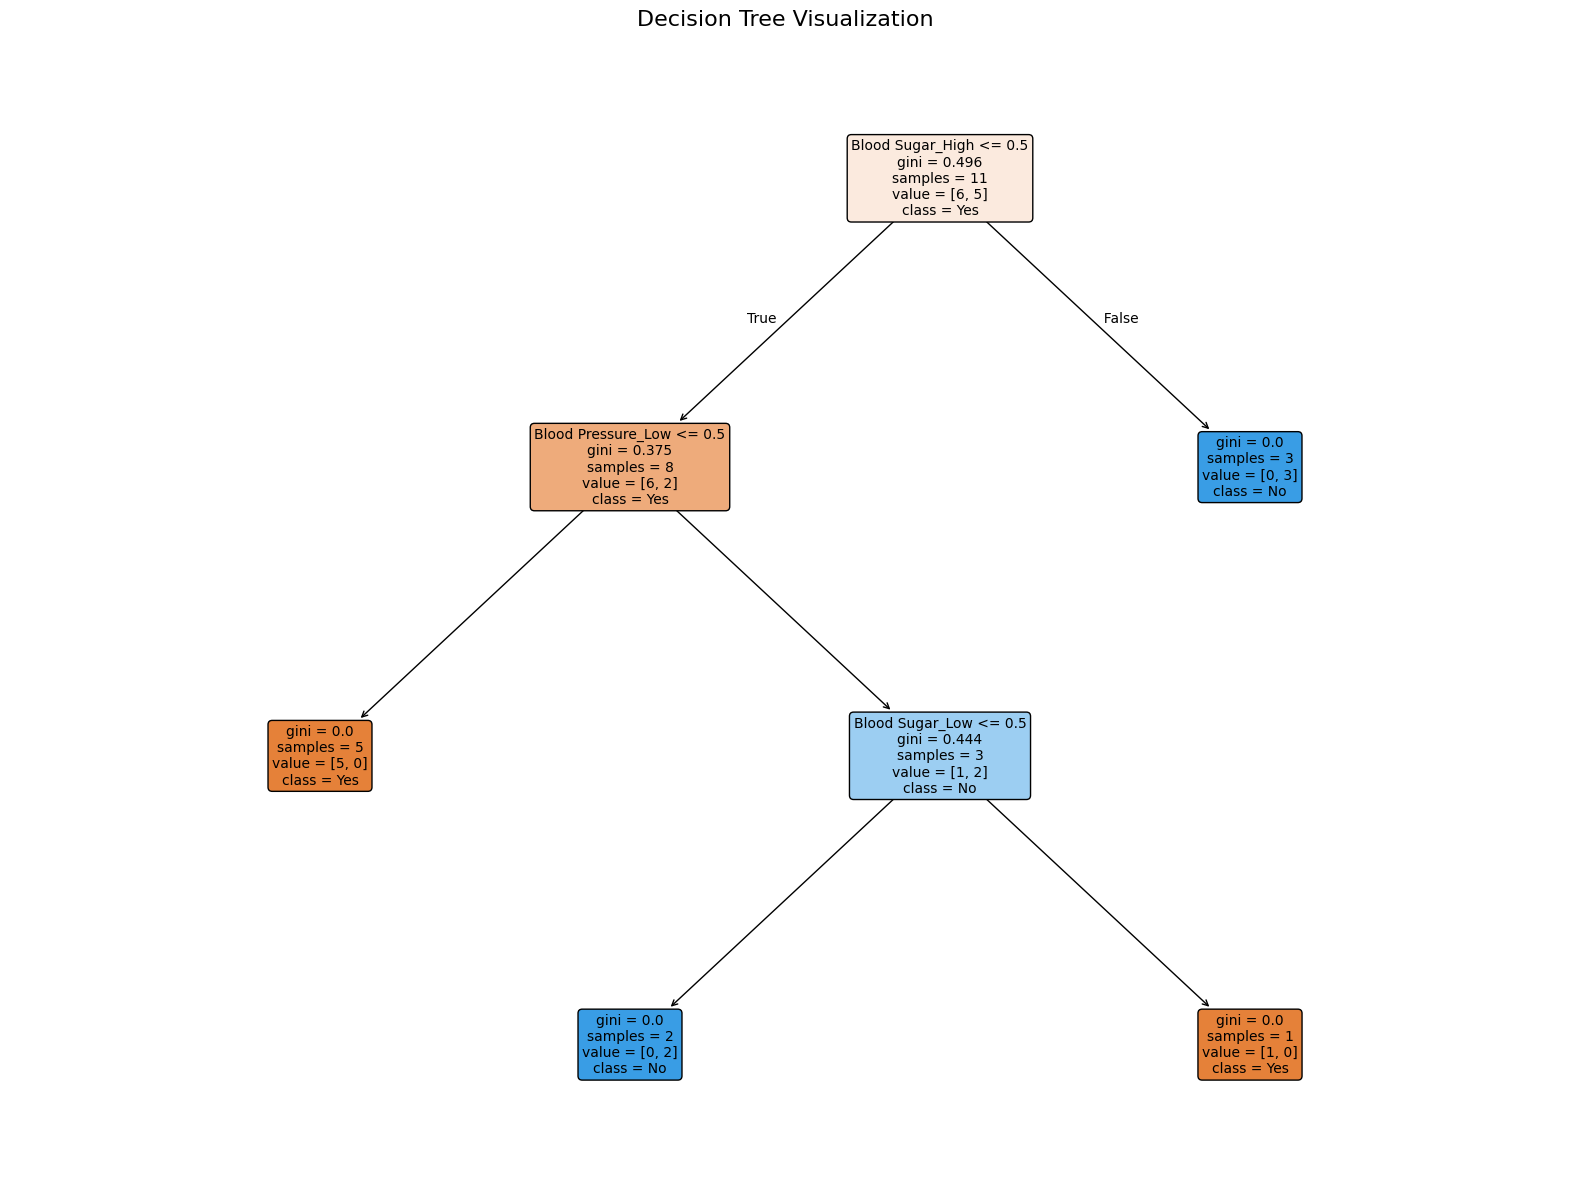

Decision Tree visualized successfully.


In [ ]:
# Create a figure and an axes object for the plot
plt.figure(figsize=(20, 15))

# Visualize the decision tree
plot_tree(dtree,
          feature_names=X.columns.tolist(),
          class_names=y.unique().tolist(),
          filled=True,
          rounded=True,
          fontsize=10)

# Add a title to the plot
plt.title('Decision Tree Visualization', fontsize=16)

# Display the plot
plt.show()

print("Decision Tree visualized successfully.")